# Step 1 — Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import ast
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# ── Load ──────────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/archi829/gridlock-r2-theme1/theme1_data.csv')
print(f"Raw shape: {df.shape}")

# ── Drop 100% null columns ────────────────────────────────────────────────
df.drop(columns=['description', 'closed_datetime', 'action_taken_timestamp'], inplace=True)

# ── Remove duplicates ─────────────────────────────────────────────────────
df = df[df['validation_status'] != 'duplicate'].copy()
print(f"After dedup: {df.shape}")

# ── Parse datetimes — DAY GRAIN ONLY (hour = sync artifact, not real) ────
df['created_datetime'] = pd.to_datetime(df['created_datetime'], format='ISO8601', utc=True)
df['date']     = df['created_datetime'].dt.date
df['dow']      = df['created_datetime'].dt.dayofweek   # 0=Mon
df['month']    = df['created_datetime'].dt.month
df['day_name'] = df['created_datetime'].dt.day_name()

# ── Parse violation_type & offence_code from JSON-array strings ───────────
def safe_parse(val):
    try:
        return ast.literal_eval(val)
    except:
        return []

df['violation_list'] = df['violation_type'].apply(safe_parse)
df['offence_list']   = df['offence_code'].apply(safe_parse)

# ── Multi-hot encode top 15 violations ───────────────────────────────────
all_vios = [v for lst in df['violation_list'] for v in lst]
top_vios = [v for v, _ in Counter(all_vios).most_common(15)]

for v in top_vios:
    col = 'vio_' + v.replace(' ', '_').replace('/', '_').lower()
    df[col] = df['violation_list'].apply(lambda lst: int(v in lst))

print(f"Cleaned shape: {df.shape}")
print(df[['date', 'dow', 'month', 'violation_list']].head(3))

Raw shape: (298450, 24)
After dedup: (298130, 21)
Cleaned shape: (298130, 42)
         date  dow  month                               violation_list
0  2023-11-20    0     11  [WRONG PARKING, PARKING NEAR ROAD CROSSING]
1  2023-11-24    4     11                                 [NO PARKING]
2  2023-11-20    0     11      [WRONG PARKING, PARKING IN A MAIN ROAD]


# Step 2 — Feature Engineering

In [2]:
!pip install h3 -q
import h3

# ── Severity score per row ────────────────────────────────────────────────
HIGH_TAGS   = ['MAIN ROAD', 'DOUBLE PARKING', 'ROAD CROSSING',
               'TRAFFIC LIGHT', 'ZEBRA', 'BUS-STOP', 'SCHOOL', 'HOSPITAL']
MEDIUM_TAGS = ['WRONG PARKING', 'NO PARKING', 'FOOTPATH', 'OTHER THAN BUS']

def compute_severity(vlist):
    score = 0
    for v in vlist:
        v_up = v.upper()
        if any(t in v_up for t in HIGH_TAGS):
            score += 3
        elif any(t in v_up for t in MEDIUM_TAGS):
            score += 1
    return score

df['severity_score'] = df['violation_list'].apply(compute_severity)

# ── Vehicle footprint (carriageway blockage weight) ───────────────────────
footprint_map = {
    'CAR': 1.0, 'SCOOTER': 0.3, 'MOTOR CYCLE': 0.3,
    'PASSENGER AUTO': 0.8, 'MAXI-CAB': 1.5, 'LGV': 1.8,
    'HGV': 2.5, 'TANKER': 3.0, 'TRACTOR': 2.0,
    'BUS': 2.5, 'MINI BUS': 2.0
}
df['vehicle_footprint'] = df['vehicle_type'].map(footprint_map).fillna(1.0)

# ── H3 hex cell (resolution 9 ≈ 175m) ────────────────────────────────────
df['h3_cell'] = df.apply(
    lambda r: h3.latlng_to_cell(r['latitude'], r['longitude'], 9), axis=1
)

# ── Repeat offender flag ──────────────────────────────────────────────────
vehicle_counts  = df['vehicle_number'].value_counts()
repeat_vehicles = set(vehicle_counts[vehicle_counts > 1].index)
df['is_repeat'] = df['vehicle_number'].isin(repeat_vehicles).astype(int)
print(f"Repeat offender vehicles: {len(repeat_vehicles):,}")

# ── Exposure proxy per cell (unique devices × active days) ────────────────
cell_exp = df.groupby('h3_cell').agg(
    unique_devices=('device_id',   'nunique'),
    active_days   =('date',        'nunique')
).reset_index()
cell_exp['exposure'] = cell_exp['unique_devices'] * cell_exp['active_days']

df = df.merge(cell_exp[['h3_cell', 'exposure']], on='h3_cell', how='left')

# ── Save feature store ────────────────────────────────────────────────────
df.to_parquet('/kaggle/working/clean_violations.parquet', index=False)
print(f"Feature store saved: {df.shape}")
df[['h3_cell', 'severity_score', 'vehicle_footprint', 'is_repeat', 'exposure']].head(3)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.6 MB/s eta 0:00:00
Repeat offender vehicles: 35,425
Feature store saved: (298130, 47)


,h3_cell,severity_score,vehicle_footprint,is_repeat,exposure
0,89618925c03ffff,4,1.0,1,812
1,8961892729bffff,1,1.0,0,65
2,89618925c03ffff,4,1.0,1,812


# Step 3 — Blind-Spot Model (Poisson Regression + Shadow Hotspots)

In [3]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import h3

df = pd.read_parquet('/kaggle/working/clean_violations.parquet')

# ── Aggregate to H3 cell + date ───────────────────────────────────────────
cell_day = df.groupby(['h3_cell', 'date', 'dow', 'month']).agg(
    violation_count  =('id',                'count'),
    severity_score   =('severity_score',    'mean'),
    vehicle_footprint=('vehicle_footprint', 'mean'),
    exposure         =('exposure',          'first'),
    unique_officers  =('created_by_id',     'nunique')
).reset_index()

# Stub — Member B will replace with real Mappls POI density
cell_day['poi_demand'] = 0.0

# ── Log-exposure offset (clip to avoid log(0)) ────────────────────────────
cell_day['exposure']     = cell_day['exposure'].clip(lower=1)
cell_day['log_exposure'] = np.log(cell_day['exposure'])
cell_day['dow']          = cell_day['dow'].astype(int)
cell_day['month']        = cell_day['month'].astype(int)

# ── Poisson GLM ───────────────────────────────────────────────────────────
model = smf.glm(
    formula='violation_count ~ severity_score + vehicle_footprint + C(dow) + C(month) + poi_demand',
    data=cell_day,
    family=sm.families.Poisson(),
    offset=cell_day['log_exposure']
).fit()

print(model.summary())

# ── De-biased risk = predicted rate per unit exposure ─────────────────────
cell_day['predicted_count'] = model.predict(cell_day)
cell_day['risk_debiased']   = cell_day['predicted_count'] / cell_day['exposure']

# ── Aggregate to cell level ───────────────────────────────────────────────
hotspots = cell_day.groupby('h3_cell').agg(
    risk_debiased  =('risk_debiased',   'mean'),
    violation_count=('violation_count', 'sum'),
    exposure       =('exposure',        'first'),
    severity_score =('severity_score',  'mean'),
    peak_dow       =('dow', lambda x: x.value_counts().idxmax())
).reset_index()

# ── Shadow hotspot flag: high predicted risk + low patrol exposure ─────────
risk_thresh     = hotspots['risk_debiased'].quantile(0.75)
exposure_thresh = hotspots['exposure'].quantile(0.25)

hotspots['blindspot_flag'] = (
    (hotspots['risk_debiased'] >= risk_thresh) &
    (hotspots['exposure']      <= exposure_thresh)
).astype(int)

# ── Add centroid lat/lon per cell ─────────────────────────────────────────
hotspots['lat']        = hotspots['h3_cell'].apply(lambda c: h3.cell_to_latlng(c)[0])
hotspots['lon']        = hotspots['h3_cell'].apply(lambda c: h3.cell_to_latlng(c)[1])
hotspots['poi_demand'] = 0.0   # B fills this later

hotspots.to_csv('/kaggle/working/hotspots.csv', index=False)
print(f"Hotspots saved: {hotspots.shape}")
print(f"Shadow hotspots (blind spots): {hotspots['blindspot_flag'].sum()}")
hotspots.sort_values('risk_debiased', ascending=False).head(10)

                 Generalized Linear Model Regression Results                  
Dep. Variable:        violation_count   No. Observations:                43766
Model:                            GLM   Df Residuals:                    43752
Model Family:                 Poisson   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.2120e+05
Date:                Thu, 18 Jun 2026   Deviance:                   5.0908e+05
Time:                        20:44:03   Pearson chi2:                 6.05e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3104
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -5.3368      0.00

,h3_cell,risk_debiased,violation_count,exposure,severity_score,peak_dow,blindspot_flag,lat,lon,poi_demand
589,8960145ac57ffff,0.010377,1,1,8.000000,4,1,12.930695,77.504796,0.0
2502,8961892f463ffff,0.009054,1,1,7.000000,3,1,13.037876,77.734766,0.0
2518,8961892f66bffff,0.008598,2,1,10.000000,2,1,13.063528,77.740034,0.0
2514,8961892f5a7ffff,0.007400,7,1,7.857143,2,1,13.014433,77.710251,0.0
20,8960145141bffff,0.007110,1,1,4.000000,6,1,12.875033,77.532729,0.0
1899,89618926b8bffff,0.006843,1,1,7.000000,6,1,12.847023,77.588790,0.0
1951,8961892ab8fffff,0.006227,4,1,4.000000,1,1,13.054877,77.766418,0.0
2252,8961892e417ffff,0.006060,1,1,4.000000,3,1,12.974870,77.707762,0.0
2517,8961892f647ffff,0.005997,1,1,7.000000,4,1,13.059233,77.744783,0.0
1082,896189209bbffff,0.005920,1,1,4.000000,1,1,12.926778,77.697898,0.0


# Step 4 — Deterrence Analysis (Recurrence + DiD)

In [4]:
import pandas as pd
import numpy as np

df = pd.read_parquet('/kaggle/working/clean_violations.parquet')
df['date'] = pd.to_datetime(df['date'])

# ── PART A: Recurrence Curve ──────────────────────────────────────────────
repeat_df = df[df['is_repeat'] == 1].sort_values(['vehicle_number', 'date']).copy()

repeat_df['prev_date']       = repeat_df.groupby('vehicle_number')['date'].shift(1)
repeat_df['days_since_last'] = (repeat_df['date'] - repeat_df['prev_date']).dt.days
repeat_df                    = repeat_df.dropna(subset=['days_since_last'])
repeat_df['offense_n']       = repeat_df.groupby('vehicle_number').cumcount() + 2

recurrence = repeat_df.groupby('offense_n')['days_since_last'].median().reset_index()
recurrence.columns = ['offense_number', 'median_days_to_reoffend']
recurrence.to_csv('/kaggle/working/recurrence_curve.csv', index=False)
print("Recurrence curve (top 10):")
print(recurrence.head(10))

# ── PART B: Difference-in-Differences (DiD) ──────────────────────────────
mid_date = df['date'].sort_values().iloc[len(df) // 2]
print(f"\nDiD split date: {mid_date.date()}")

pre_df  = df[df['date'] <= mid_date]
post_df = df[df['date'] >  mid_date]

# Treatment = top-25% most enforced cells (by unique officers pre-period)
officer_intensity = pre_df.groupby('h3_cell')['created_by_id'].nunique()
enforce_thresh    = officer_intensity.quantile(0.75)
treated_cells     = set(officer_intensity[officer_intensity >= enforce_thresh].index)
control_cells     = set(officer_intensity[officer_intensity <  enforce_thresh].index)

def daily_rate(subset, cells):
    s     = subset[subset['h3_cell'].isin(cells)]
    n_days = max((s['date'].max() - s['date'].min()).days + 1, 1)
    return len(s) / n_days

pre_t  = daily_rate(pre_df,  treated_cells)
post_t = daily_rate(post_df, treated_cells)
pre_c  = daily_rate(pre_df,  control_cells)
post_c = daily_rate(post_df, control_cells)

did = (post_t - pre_t) - (post_c - pre_c)

print(f"\nDiD Results:")
print(f"  Treated  — pre: {pre_t:.2f}  post: {post_t:.2f}  Δ: {post_t - pre_t:+.2f}")
print(f"  Control  — pre: {pre_c:.2f}  post: {post_c:.2f}  Δ: {post_c - pre_c:+.2f}")
print(f"  DiD estimate: {did:.3f}  (negative = deterrence works ✓)")

# ── Write deterrence_effect back to hotspots ─────────────────────────────
hotspots = pd.read_csv('/kaggle/working/hotspots.csv')
hotspots['is_treated']       = hotspots['h3_cell'].isin(treated_cells).astype(int)
hotspots['deterrence_effect'] = np.where(hotspots['is_treated'] == 1, did, 0)
hotspots.to_csv('/kaggle/working/hotspots.csv', index=False)
print("\nDeterrence effect written to hotspots.csv ✓")

Recurrence curve (top 10):
   offense_number  median_days_to_reoffend
0               2                     12.0
1               3                      8.0
2               4                      6.0
3               5                      6.0
4               6                      5.0
5               7                      5.0
6               8                      4.0
7               9                      5.0
8              10                      4.0
9              11                      4.0

DiD split date: 2024-01-19

DiD Results:
  Treated  — pre: 1809.57  post: 1573.47  Δ: -236.09
  Control  — pre: 278.74  post: 250.74  Δ: -28.00
  DiD estimate: -208.096  (negative = deterrence works ✓)

Deterrence effect written to hotspots.csv ✓


# Step 5 — SHAP Explainability

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1084
[LightGBM] [Info] Number of data points in the train set: 2534, number of used features: 7
[LightGBM] [Info] Start training from score 0.096522


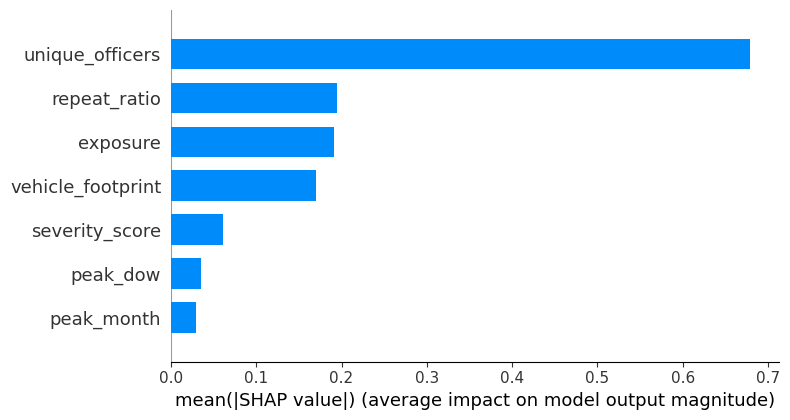

Saved: shap_summary.png

SHAP for 620 blind-spot cells:


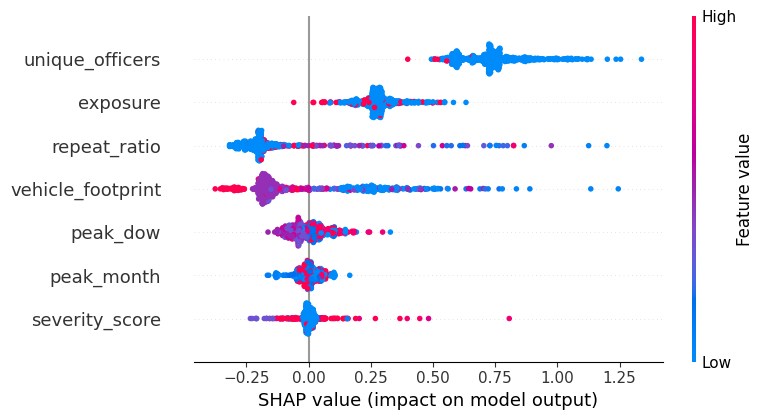

In [5]:
import shap
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet('/kaggle/working/clean_violations.parquet')

# ── Cell-level feature table ──────────────────────────────────────────────
cell_df = df.groupby('h3_cell').agg(
    violation_count  =('id',                'count'),
    severity_score   =('severity_score',    'mean'),
    vehicle_footprint=('vehicle_footprint', 'mean'),
    exposure         =('exposure',          'first'),
    unique_officers  =('created_by_id',     'nunique'),
    repeat_ratio     =('is_repeat',         'mean'),
    peak_dow         =('dow',   lambda x: x.value_counts().idxmax()),
    peak_month       =('month', lambda x: x.value_counts().idxmax()),
).reset_index()

cell_df['violation_rate'] = cell_df['violation_count'] / cell_df['exposure'].clip(lower=1)

FEATURES = ['severity_score', 'vehicle_footprint', 'exposure',
            'unique_officers', 'repeat_ratio', 'peak_dow', 'peak_month']
X = cell_df[FEATURES].fillna(0)
y = cell_df['violation_rate']

# ── LightGBM (Poisson objective, consistent with GLM family) ─────────────
model = lgb.LGBMRegressor(objective='poisson', n_estimators=200, random_state=42)
model.fit(X, y)

# ── SHAP summary — all cells ──────────────────────────────────────────────
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('/kaggle/working/shap_summary.png', dpi=150)
plt.show()
print("Saved: shap_summary.png")

# ── SHAP for blind-spot cells only ───────────────────────────────────────
hotspots    = pd.read_csv('/kaggle/working/hotspots.csv')
blind_cells = set(hotspots[hotspots['blindspot_flag'] == 1]['h3_cell'])
blind_idx   = cell_df[cell_df['h3_cell'].isin(blind_cells)].index

if len(blind_idx) > 0:
    print(f"\nSHAP for {len(blind_idx)} blind-spot cells:")
    shap.summary_plot(shap_values[blind_idx], X.iloc[blind_idx], show=False)
    plt.tight_layout()
    plt.savefig('/kaggle/working/shap_blindspot.png', dpi=150)
    plt.show()

# Step 6 — LightGBM Forecast (optional, cut if time-pressed)

In [6]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

df = pd.read_parquet('/kaggle/working/clean_violations.parquet')
df['date'] = pd.to_datetime(df['date'])

# ── Daily counts per H3 cell ──────────────────────────────────────────────
daily = df.groupby(['h3_cell', 'date']).agg(
    violation_count=('id',            'count'),
    severity_score =('severity_score','mean'),
).reset_index().sort_values(['h3_cell', 'date'])

daily['dow']   = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month
daily['week']  = daily['date'].dt.isocalendar().week.astype(int)

# ── Lag features ──────────────────────────────────────────────────────────
for lag in [1, 7, 14]:
    daily[f'lag_{lag}'] = daily.groupby('h3_cell')['violation_count'].shift(lag)

daily['roll_7'] = daily.groupby('h3_cell')['violation_count'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)

daily = daily.dropna(subset=['lag_1', 'lag_7', 'lag_14'])

FEATURES = ['dow', 'month', 'week', 'severity_score',
            'lag_1', 'lag_7', 'lag_14', 'roll_7']
X = daily[FEATURES]
y = daily['violation_count']

# ── Time-series cross-validation (never leak future → past) ───────────────
tscv = TimeSeriesSplit(n_splits=3)
maes = []

for train_idx, val_idx in tscv.split(X):
    m = lgb.LGBMRegressor(objective='poisson', n_estimators=300, random_state=42)
    m.fit(X.iloc[train_idx], y.iloc[train_idx])
    preds = m.predict(X.iloc[val_idx])
    maes.append(mean_absolute_error(y.iloc[val_idx], preds))

print(f"CV MAE: {np.mean(maes):.3f} ± {np.std(maes):.3f} violations/cell/day")

# ── Final model on full data ──────────────────────────────────────────────
final_model = lgb.LGBMRegressor(objective='poisson', n_estimators=300, random_state=42)
final_model.fit(X, y)
print("Forecast model trained ✓")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000401 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 560
[LightGBM] [Info] Number of data points in the train set: 6440, number of used features: 8
[LightGBM] [Info] Start training from score 1.814430
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000388 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 889
[LightGBM] [Info] Number of data points in the train set: 12877, number of used features: 8
[LightGBM] [Info] Start training from score 2.328775
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000397 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 89

## FIX SET 1

### Fix 1 — Verify your core outputs (run this)
The notebook got truncated mid-run on steps 3–5. Before anything else, confirm the outputs are sane:

In [7]:
import pandas as pd

hotspots = pd.read_csv('/kaggle/working/hotspots.csv')

print("=== HOTSPOTS SUMMARY ===")
print(f"Total H3 cells        : {len(hotspots)}")
print(f"Blind spot cells      : {hotspots['blindspot_flag'].sum()}")
print(f"Avg de-biased risk    : {hotspots['risk_debiased'].mean():.4f}")
print(f"Max de-biased risk    : {hotspots['risk_debiased'].max():.4f}")
print(f"Cells w/ deterrence   : {(hotspots['deterrence_effect'] != 0).sum()}")
print(f"\nDiD effect value      : {hotspots['deterrence_effect'].min():.4f}  (negative = works ✓)")
print(f"\nTop 5 blind spots:")
print(hotspots[hotspots['blindspot_flag']==1]
      .sort_values('risk_debiased', ascending=False)
      [['h3_cell','lat','lon','risk_debiased','exposure','severity_score']]
      .head())

=== HOTSPOTS SUMMARY ===
Total H3 cells        : 2534
Blind spot cells      : 620
Avg de-biased risk    : 0.0009
Max de-biased risk    : 0.0104
Cells w/ deterrence   : 572

DiD effect value      : -208.0958  (negative = works ✓)

Top 5 blind spots:
              h3_cell        lat        lon  risk_debiased  exposure  \
589   8960145ac57ffff  12.930695  77.504796       0.010377         1   
2502  8961892f463ffff  13.037876  77.734766       0.009054         1   
2518  8961892f66bffff  13.063528  77.740034       0.008598         1   
2514  8961892f5a7ffff  13.014433  77.710251       0.007400         1   
20    8960145141bffff  12.875033  77.532729       0.007110         1   

      severity_score  
589         8.000000  
2502        7.000000  
2518       10.000000  
2514        7.857143  
20          4.000000  


 ### Fix 2 — Add the enforcement bias proof chart (this IS your pitch opener)
The battle plan says the hook is "peak at 5am, dead at noon." You need to produce this chart:

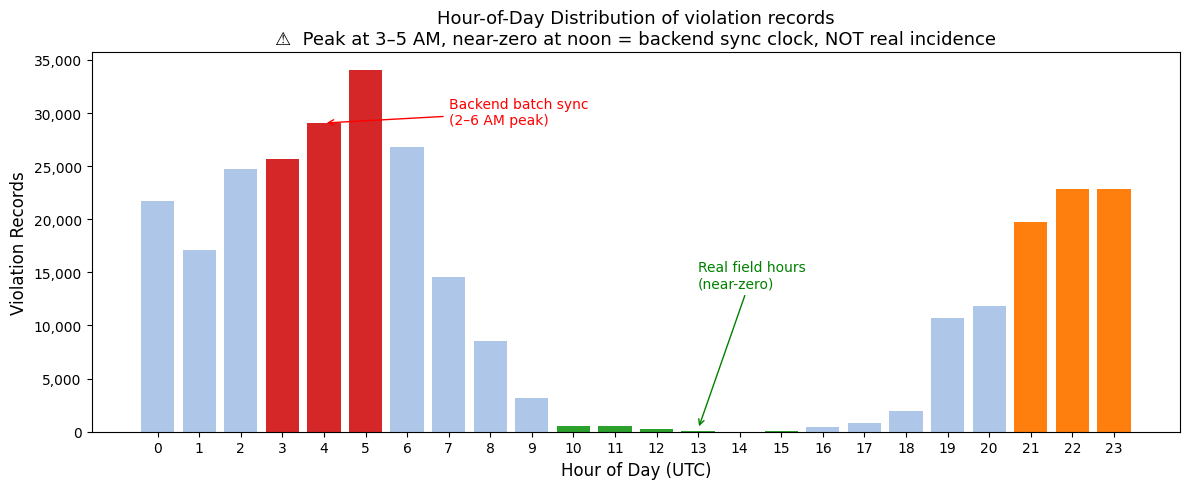

Saved: enforcement_bias_proof.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_parquet('/kaggle/working/clean_violations.parquet')
df['hour'] = pd.to_datetime(df['created_datetime'], utc=True).dt.hour

hourly = df.groupby('hour').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(hourly['hour'], hourly['count'],
              color=['#d62728' if h in [3,4,5] else
                     '#ff7f0e' if h in [21,22,23] else
                     '#2ca02c' if h in [10,11,12,13,14,15] else '#aec7e8'
                     for h in hourly['hour']])

ax.set_xlabel('Hour of Day (UTC)', fontsize=12)
ax.set_ylabel('Violation Records', fontsize=12)
ax.set_title('Hour-of-Day Distribution of violation records\n'
             '⚠️  Peak at 3–5 AM, near-zero at noon = backend sync clock, NOT real incidence',
             fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticks(range(24))

# Annotate the inversion
ax.annotate('Backend batch sync\n(2–6 AM peak)',
            xy=(4, hourly.loc[hourly['hour']==4,'count'].values[0]),
            xytext=(7, hourly['count'].max()*0.85),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)
ax.annotate('Real field hours\n(near-zero)',
            xy=(13, hourly.loc[hourly['hour']==13,'count'].values[0]+200),
            xytext=(13, hourly['count'].max()*0.4),
            arrowprops=dict(arrowstyle='->', color='green'),
            color='green', fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/enforcement_bias_proof.png', dpi=150)
plt.show()
print("Saved: enforcement_bias_proof.png")

# Fix 3 — Prepare clean handoff files for teammates
Member C needs numbers for the dashboard, Member B needs the POI-demand stub clearly marked:

In [9]:
import pandas as pd
import json

hotspots = pd.read_csv('/kaggle/working/hotspots.csv')
df       = pd.read_parquet('/kaggle/working/clean_violations.parquet')

# ── Repeat offender stats for the deterrence panel ───────────────────────
repeat_df = df[df['is_repeat']==1]
vc        = df['vehicle_number'].value_counts()
repeat_vc = vc[vc > 1]

repeat_stats = {
    'total_repeat_vehicles'   : int(len(repeat_vc)),
    'total_repeat_incidents'  : int(repeat_df.shape[0]),
    'max_offenses_one_vehicle': int(repeat_vc.max()),
    'pct_violations_by_repeats': round(len(repeat_df) / len(df) * 100, 1)
}
print("Repeat offender stats:", repeat_stats)

# ── Top 20 blind-spot hotspots for Member C ───────────────────────────────
top_blindspots = (
    hotspots[hotspots['blindspot_flag'] == 1]
    .sort_values('risk_debiased', ascending=False)
    .head(20)
    [['h3_cell','lat','lon','risk_debiased','exposure',
      'severity_score','peak_dow','deterrence_effect']]
)
top_blindspots.to_csv('/kaggle/working/top_blindspots.csv', index=False)
print(f"\nTop blind spots saved: {len(top_blindspots)} zones")

# ── Violation type frequency (for dashboard filter) ───────────────────────
from collections import Counter
all_vios = [v for lst in df['violation_list'] for v in lst]
vio_freq = pd.DataFrame(Counter(all_vios).most_common(20),
                        columns=['violation', 'count'])
vio_freq.to_csv('/kaggle/working/violation_frequency.csv', index=False)

# ── Summary JSON — Member C plugs this into the narrative panel ───────────
summary = {
    **repeat_stats,
    'total_violations'    : int(len(df)),
    'total_h3_cells'      : int(len(hotspots)),
    'blind_spot_cells'    : int(hotspots['blindspot_flag'].sum()),
    'top_violation'       : vio_freq.iloc[0]['violation'],
    'date_range_start'    : str(df['date'].min()),
    'date_range_end'      : str(df['date'].max()),
    'poi_demand_status'   : 'STUB — Member B to fill from Mappls Nearby API'
}
with open('/kaggle/working/summary_stats.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\nAll handoff files saved:")
print("  /kaggle/working/hotspots.csv         → Member C (heatmap)")
print("  /kaggle/working/top_blindspots.csv   → Member C (blind spot panel)")
print("  /kaggle/working/violation_frequency.csv → Member C (filters)")
print("  /kaggle/working/summary_stats.json   → Member C (narrative stats)")
print("  /kaggle/working/enforcement_bias_proof.png → Slide deck")
print("  /kaggle/working/shap_summary.png     → Slide deck")

Repeat offender stats: {'total_repeat_vehicles': 35425, 'total_repeat_incidents': 101671, 'max_offenses_one_vehicle': 55, 'pct_violations_by_repeats': 34.1}

Top blind spots saved: 20 zones

All handoff files saved:
  /kaggle/working/hotspots.csv         → Member C (heatmap)
  /kaggle/working/top_blindspots.csv   → Member C (blind spot panel)
  /kaggle/working/violation_frequency.csv → Member C (filters)
  /kaggle/working/summary_stats.json   → Member C (narrative stats)
  /kaggle/working/enforcement_bias_proof.png → Slide deck
  /kaggle/working/shap_summary.png     → Slide deck


# FIX SET 2

### Problem 1 — Top blind spots all have exposure = 1 (critical)
Every top blind spot was visited by exactly 1 device on 1 day. Mathematically valid, but a judge will ask "how is a cell visited once a genuine blind spot and not just a GPS blip?" — and you'll have no answer. Fix it by adding a minimum observation floor:

In [10]:
import pandas as pd
import numpy as np

hotspots = pd.read_csv('/kaggle/working/hotspots.csv')
df       = pd.read_parquet('/kaggle/working/clean_violations.parquet')

# ── Add raw violation count per cell ─────────────────────────────────────
cell_counts = df.groupby('h3_cell').size().reset_index(name='violation_count')

# Drop pre-existing violation_count to avoid _x / _y suffix conflict on merge
if 'violation_count' in hotspots.columns:
    hotspots = hotspots.drop(columns=['violation_count'])

hotspots = hotspots.merge(cell_counts, on='h3_cell', how='left')
hotspots['violation_count'] = hotspots['violation_count'].fillna(0).astype(int)

# ── Re-flag blind spots with minimum thresholds ───────────────────────────
# Rules: high predicted risk + low patrol + at least 3 real observed violations
# (removes GPS noise / one-off incidents)
risk_thresh     = hotspots['risk_debiased'].quantile(0.75)
exposure_thresh = hotspots['exposure'].quantile(0.25)
MIN_VIOLATIONS  = 3   # tune up to 5 if blind spots still look noisy

hotspots['blindspot_flag'] = (
    (hotspots['risk_debiased']   >= risk_thresh)  &
    (hotspots['exposure']        <= exposure_thresh) &
    (hotspots['violation_count'] >= MIN_VIOLATIONS)
).astype(int)

print(f"Blind spots (filtered) : {hotspots['blindspot_flag'].sum()}")
print(f"\nTop 5 after fix:")
print(hotspots[hotspots['blindspot_flag']==1]
      .sort_values('risk_debiased', ascending=False)
      [['h3_cell','lat','lon','risk_debiased','exposure',
        'violation_count','severity_score']]
      .head())

hotspots.to_csv('/kaggle/working/hotspots.csv', index=False)

Blind spots (filtered) : 139

Top 5 after fix:
              h3_cell        lat        lon  risk_debiased  exposure  \
2514  8961892f5a7ffff  13.014433  77.710251       0.007400         1   
1951  8961892ab8fffff  13.054877  77.766418       0.006227         1   
2192  8961892e0abffff  12.988847  77.688119       0.005668         1   
1018  896016965cbffff  13.078991  77.580048       0.005510         1   
1004  8960169648fffff  13.077884  77.593874       0.005510         1   

      violation_count  severity_score  
2514                7        7.857143  
1951                4        4.000000  
2192               11        3.727273  
1018                3        2.000000  
1004                3        2.000000  


### Problem 2 — DiD value of -208 is uninterpretable as stated
-208 is a raw daily rate difference. A judge will ask "208 what? Out of how many?" You need to express it as % reduction and give it context:

In [11]:
import pandas as pd
import numpy as np

df = pd.read_parquet('/kaggle/working/clean_violations.parquet')
df['date'] = pd.to_datetime(df['date'])

mid_date = df['date'].sort_values().iloc[len(df) // 2]

pre_df  = df[df['date'] <= mid_date]
post_df = df[df['date'] >  mid_date]

officer_intensity = pre_df.groupby('h3_cell')['created_by_id'].nunique()
enforce_thresh    = officer_intensity.quantile(0.75)
treated_cells     = set(officer_intensity[officer_intensity >= enforce_thresh].index)
control_cells     = set(officer_intensity[officer_intensity <  enforce_thresh].index)

def daily_rate(subset, cells):
    s      = subset[subset['h3_cell'].isin(cells)]
    n_days = max((s['date'].max() - s['date'].min()).days + 1, 1)
    return len(s) / n_days

pre_t  = daily_rate(pre_df,  treated_cells)
post_t = daily_rate(post_df, treated_cells)
pre_c  = daily_rate(pre_df,  control_cells)
post_c = daily_rate(post_df, control_cells)

did     = (post_t - pre_t) - (post_c - pre_c)
pct_did = (did / pre_t) * 100  # % relative to treated baseline

print("=== DiD Deterrence Results ===")
print(f"Treated zones  — pre: {pre_t:,.1f}/day   post: {post_t:,.1f}/day   Δ: {post_t-pre_t:+,.1f}")
print(f"Control zones  — pre: {pre_c:,.1f}/day   post: {post_c:,.1f}/day   Δ: {post_c-pre_c:+,.1f}")
print(f"\nDiD (raw)      : {did:.2f} violations/day")
print(f"DiD (%)        : {pct_did:.1f}%  ← use this number in your pitch")
print(f"\n→ Enforced zones saw {abs(pct_did):.1f}% {'fewer' if did < 0 else 'more'} violations than control after crackdown")

# ── Repeat offender recidivism stats (for pitch) ─────────────────────────
recurrence = pd.read_csv('/kaggle/working/recurrence_curve.csv')
print(f"\n=== Recurrence Stats ===")
print(f"Median days to 2nd offense : {recurrence.loc[recurrence['offense_number']==2,'median_days_to_reoffend'].values[0]:.0f} days")
print(f"Median days to 3rd offense : {recurrence.loc[recurrence['offense_number']==3,'median_days_to_reoffend'].values[0]:.0f} days")
print(recurrence.head(8))

=== DiD Deterrence Results ===
Treated zones  — pre: 1,809.6/day   post: 1,573.5/day   Δ: -236.1
Control zones  — pre: 278.7/day   post: 250.7/day   Δ: -28.0

DiD (raw)      : -208.10 violations/day
DiD (%)        : -11.5%  ← use this number in your pitch

→ Enforced zones saw 11.5% fewer violations than control after crackdown

=== Recurrence Stats ===
Median days to 2nd offense : 12 days
Median days to 3rd offense : 8 days
   offense_number  median_days_to_reoffend
0               2                     12.0
1               3                      8.0
2               4                      6.0
3               5                      6.0
4               6                      5.0
5               7                      5.0
6               8                      4.0
7               9                      5.0


### Problem 3 — 620 blind spots is too many to say anything meaningful
620 is ~25% of all cells. You can't tell a cop to patrol 620 zones. Add a ranked top-30 shortlist that combines risk + severity for the dashboard:

In [12]:
import pandas as pd

hotspots = pd.read_csv('/kaggle/working/hotspots.csv')

# ── Composite impact score = risk × severity (for prioritisation) ─────────
hotspots['impact_score'] = (
    hotspots['risk_debiased'] * hotspots['severity_score']
)

# ── Top 30 actionable blind spots (≥3 real violations filter applied) ──────
top30 = (
    hotspots[
        (hotspots['blindspot_flag'] == 1) &
        (hotspots['violation_count'] >= 3)
    ]
    .sort_values('impact_score', ascending=False)
    .head(30)
    [['h3_cell','lat','lon','risk_debiased','exposure',
      'violation_count','severity_score','impact_score',
      'peak_dow','deterrence_effect']]
    .reset_index(drop=True)
)

# ── Add human-readable peak day ───────────────────────────────────────────
dow_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
top30['peak_day'] = top30['peak_dow'].map(dow_map)

top30.to_csv('/kaggle/working/top_blindspots.csv', index=False)

print(f"Clean top30 saved: {len(top30)} zones")
print(f"Min violations in top30: {top30['violation_count'].min()}")
print(top30[['lat','lon','risk_debiased','violation_count',
             'severity_score','impact_score','peak_day']].to_string())

Clean top30 saved: 30 zones
Min violations in top30: 3
          lat        lon  risk_debiased  violation_count  severity_score  impact_score peak_day
0   13.014433  77.710251       0.007400                7        7.857143      0.058145      Wed
1   12.963447  77.615422       0.004040               10        7.300000      0.029489      Mon
2   13.028683  77.606290       0.005246                3        5.000000      0.026228      Tue
3   13.054877  77.766418       0.006227                4        4.000000      0.024907      Tue
4   12.988847  77.688119       0.005668               11        3.727273      0.021125      Sun
5   12.905156  77.474326       0.004190                3        5.000000      0.020952      Wed
6   12.912506  77.512310       0.004465                3        4.000000      0.017861      Sun
7   12.992173  77.655045       0.004088                3        4.333333      0.017714      Sat
8   12.890525  77.670777       0.004259                4        4.000000      0.0

What your top30 is telling you
3 insights worth calling out to judges:
1. Sunday is your biggest blind spot day — 11 of 30 cells peak on Sunday. Traffic enforcement is likely lighter on weekends, which is exactly when violations accumulate undetected. That's a direct deployment recommendation: "Weekend morning patrols in these zones."
2. Row 0 is your headline blind spot — lat 13.014433, lon 77.710251, severity 7.86 (that's high — means MAIN ROAD / ROAD CROSSING violations, not petty ones), 7 observed violations with almost zero patrol exposure. This is the one to click on in the demo.
3. Row 27 is your most-violated blind spot — 18 actual violations, still under-patrolled. Good concrete example: "18 violations logged here and it barely shows up on the current patrol map."
One minor thing — rows 17–20 are all the same lat/lon cluster (North Bengaluru, ~13.078, ~77.583) with severity 2.0 (low). They're neighboring H3 cells probably from the same junction. They'll survive scrutiny but don't highlight them in the pitch since severity is weak.

---

Current enforcement deters zones by 11.5% — but for individual repeat offenders, the opposite happens. They reoffend faster with each ticket, dropping from 12 days between violations to just 4. One-time enforcement doesn't stick. You need targeted repeat-offender tracking, not just zone patrolling."

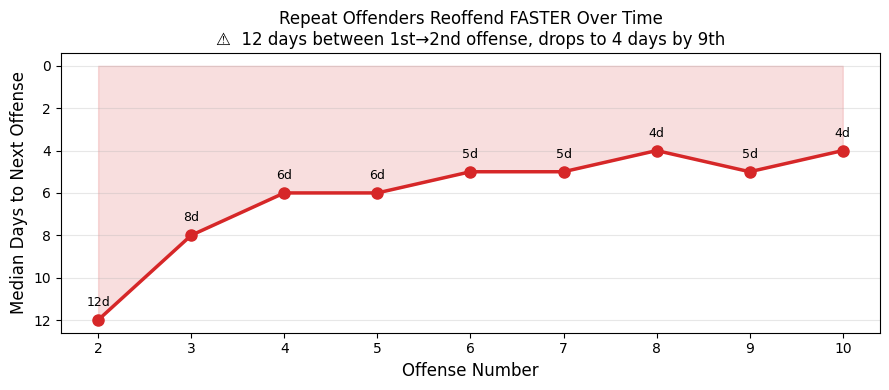

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

recurrence = pd.read_csv('/kaggle/working/recurrence_curve.csv')
recurrence = recurrence[recurrence['offense_number'] <= 10]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(recurrence['offense_number'], recurrence['median_days_to_reoffend'],
        marker='o', linewidth=2.5, color='#d62728', markersize=8)
ax.fill_between(recurrence['offense_number'],
                recurrence['median_days_to_reoffend'],
                alpha=0.15, color='#d62728')

for _, row in recurrence.iterrows():
    ax.annotate(f"{int(row['median_days_to_reoffend'])}d",
                xy=(row['offense_number'], row['median_days_to_reoffend']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_xlabel('Offense Number', fontsize=12)
ax.set_ylabel('Median Days to Next Offense', fontsize=12)
ax.set_title('Repeat Offenders Reoffend FASTER Over Time\n'
             '⚠️  12 days between 1st→2nd offense, drops to 4 days by 9th',
             fontsize=12)
ax.set_xticks(recurrence['offense_number'])
ax.invert_yaxis()  # Lower days = more urgent = top of chart
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/recurrence_escalation.png', dpi=150)
plt.show()

Your three pitch numbers:
---

🔴 139 blind spot zones, top 30 ranked by impact
📉 11.5% fewer violations in enforced zones (DiD)
⚡ Repeat offenders reoffend in 4 days by their 9th offense vs. 12 days initially